<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/(x)_%3D_x2_%E2%88%92_1_x_%E2%88%92_1_%3D_x_%2B_1%2C_x_%E2%88%88_%5B0%2C_2%5D%2C_x%CC%B8_%3D_1%2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1205264939.py:28: RuntimeWarning: invalid value encountered in divide
  y = (x**2 - 1.0) / (x - 1.0)


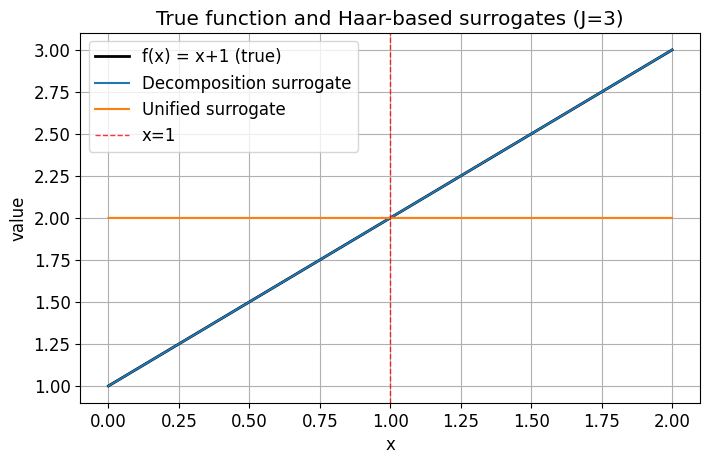

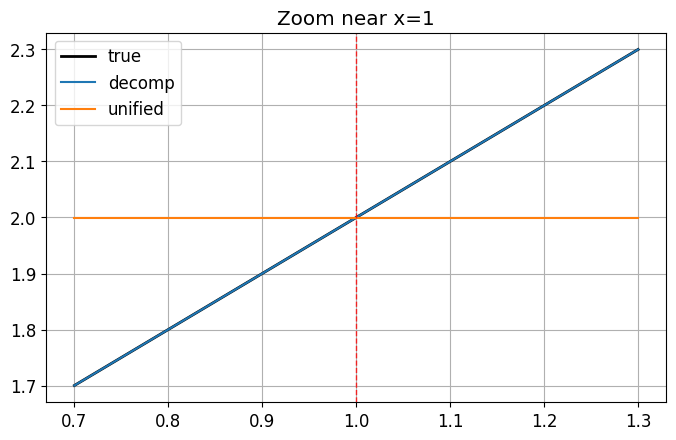

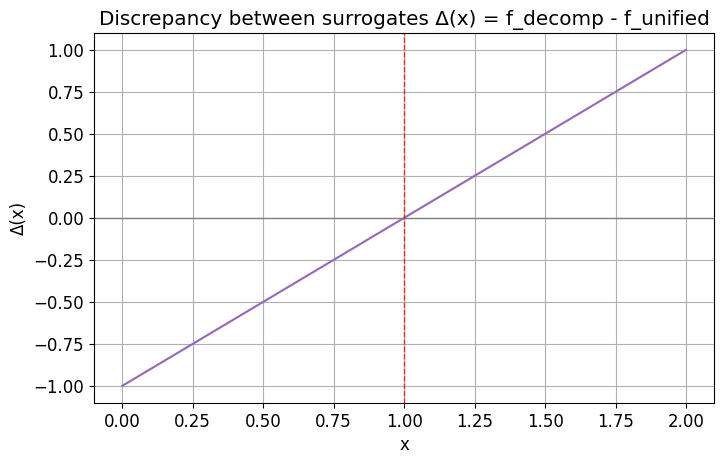

Max |Δ(x)| ≈ 9.995117e-01 at x ≈ 0.00000
L2 error (unified,  J=3): 6.656909e-01
L2 error (decomp., J=3): 0.000000e+00


/tmp/ipython-input-1205264939.py:154: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz((y_hat - y_ref)**2, x)


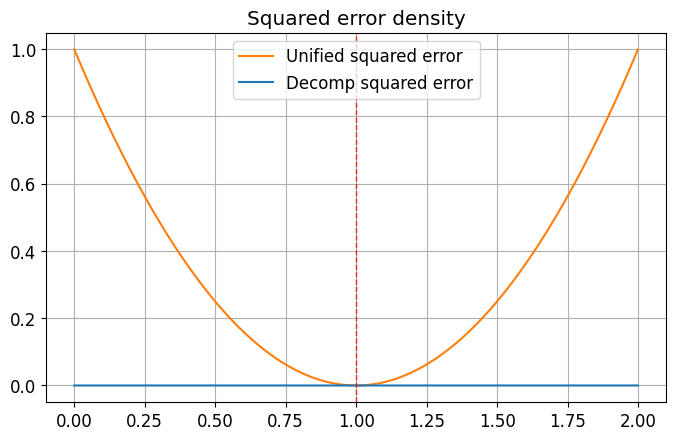

In [1]:
# ============================================================
# Google Colab: Haar Regularization for f(x) = (x^2 - 1)/(x - 1)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 12,
    "figure.figsize": (8, 4.8),
    "axes.grid": True
})

# PyWavelets (Haar transform) -------------------------------
try:
    import pywt
except ImportError:
    !pip install PyWavelets
    import pywt

# ------------------------------------------------------------
# 1. True function with removable discontinuity
# ------------------------------------------------------------
def f_raw(x):
    """Original expression (with removable singularity at x=1)."""
    x = np.asarray(x)
    y = (x**2 - 1.0) / (x - 1.0)
    return y

def f_true(x):
    """Analytically simplified form: f(x) = x + 1."""
    x = np.asarray(x)
    return x + 1.0

# Grid on [0,2]
N = 2**11  # 2048-point grid for good Haar compatibility
x = np.linspace(0.0, 2.0, N, endpoint=False)

# Evaluate the raw function, handling x=1 carefully
y_raw = f_raw(x)
# Replace possible NaN at x=1 by the true limit x+1
y_raw = np.where(np.isfinite(y_raw), y_raw, f_true(x))

y_true = f_true(x)


# ------------------------------------------------------------
# 2. Haar truncation helpers
# ------------------------------------------------------------
def haar_truncation(y, J, wavelet='haar'):
    """
    Apply Haar wavelet truncation up to level J (keep scales ≥ J, discard finer ones).
    y      : 1D array of samples
    J      : truncation depth (coarser = smaller J)
    returns: truncated (regularized) signal y_J
    """
    y = np.asarray(y)
    w = pywt.Wavelet(wavelet)
    max_level = pywt.dwt_max_level(data_len=len(y), filter_len=w.dec_len)
    J = min(J, max_level)

    # Full decomposition at max_level
    coeffs = pywt.wavedec(y, w, level=max_level, mode='periodization')
    # coeffs structure: [cA_max, cD_max, cD_{max-1}, ..., cD_1]
    cA = coeffs[0]
    details = coeffs[1:]

    # Keep detail levels >= J, zero out finer levels (< J)
    # details[idx] corresponds to level L = max_level - idx
    for idx, d in enumerate(details):
        level = max_level - idx  # L = max, max-1, ..., 1
        if level < J:
            details[idx] = np.zeros_like(d)

    coeffs_trunc = [cA] + details
    y_trunc = pywt.waverec(coeffs_trunc, w, mode='periodization')

    # Ensure same length as input
    return y_trunc[:len(y)]


def haar_unified_constant(y, wavelet='haar'):
    """
    Unified strategy: keep only the coarsest scaling coefficient (global mean),
    discard all Haar detail coefficients. This yields an almost constant surrogate.
    """
    y = np.asarray(y)
    w = pywt.Wavelet(wavelet)
    coeffs = pywt.wavedec(y, w, mode='periodization')
    cA = coeffs[0]
    # Zero out all detail coefficients
    details_zero = [np.zeros_like(d) for d in coeffs[1:]]
    y_trunc = pywt.waverec([cA] + details_zero, w, mode='periodization')
    return y_trunc[:len(y)]


# ------------------------------------------------------------
# 3. Decomposition vs Unified strategies
# ------------------------------------------------------------
J = 3  # truncation level (as in the LaTeX example)

# Structural decomposition:
#   f(x) = f_c(x) + f_d(x)
# Here f_c(x) = x + 1 (smooth), f_d(x) = raw - f_c (singular part)
f_c = f_true(x)
f_d = y_raw - f_c  # ideally zero everywhere except a small vicinity of x=1

# --- Decomposition strategy: Haar only on the singular part ---
f_d_H = haar_truncation(f_d, J=J, wavelet='haar')
y_decomp = f_c + f_d_H

# --- Unified strategy: Haar on the full function (collapse to constant) ---
y_unified = haar_unified_constant(y_raw, wavelet='haar')


# ------------------------------------------------------------
# 4. Plots: true vs surrogates
# ------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(x, y_true, label="f(x) = x+1 (true)", color="black", linewidth=2)
ax.plot(x, y_decomp, label="Decomposition surrogate", color="tab:blue")
ax.plot(x, y_unified, label="Unified surrogate", color="tab:orange")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.8, label="x=1")
ax.set_xlabel("x"); ax.set_ylabel("value")
ax.set_title(f"True function and Haar-based surrogates (J={J})")
ax.legend(); plt.show()

# Zoom near x=1
mask_zoom = (x >= 0.7) & (x <= 1.3)
fig, ax = plt.subplots()
ax.plot(x[mask_zoom], y_true[mask_zoom], color="black", linewidth=2, label="true")
ax.plot(x[mask_zoom], y_decomp[mask_zoom], color="tab:blue", label="decomp")
ax.plot(x[mask_zoom], y_unified[mask_zoom], color="tab:orange", label="unified")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Zoom near x=1"); ax.legend(); plt.show()

# ------------------------------------------------------------
# 5. Discrepancy and L2 errors
# ------------------------------------------------------------
delta = y_decomp - y_unified

fig, ax = plt.subplots()
ax.plot(x, delta, color="tab:purple")
ax.axhline(0.0, color="gray", linewidth=1)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.8)
ax.set_xlabel("x"); ax.set_ylabel("Δ(x)")
ax.set_title("Discrepancy between surrogates Δ(x) = f_decomp - f_unified")
plt.show()

print(f"Max |Δ(x)| ≈ {np.max(np.abs(delta)):.6e} at x ≈ {x[np.argmax(np.abs(delta))]:.5f}")

def l2_error(y_hat, y_ref, x):
    return np.trapz((y_hat - y_ref)**2, x)

E_unified = l2_error(y_unified, y_true, x)
E_decomp = l2_error(y_decomp, y_true, x)

print(f"L2 error (unified,  J={J}): {E_unified:.6e}")
print(f"L2 error (decomp., J={J}): {E_decomp:.6e}")

# Squared error density
fig, ax = plt.subplots()
ax.plot(x, (y_unified - y_true)**2, label="Unified squared error", color="tab:orange")
ax.plot(x, (y_decomp - y_true)**2, label="Decomp squared error", color="tab:blue")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Squared error density"); ax.legend(); plt.show()
